# Part 3: Estimation
The aim of this part is to estimate the matrix $Q$ from the kind of observations we may encounter in practice.

### Importing the necessary packages

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Task 12
We run the standard simulation using the original $Q$ matrix from part 2. However, instead of just recording the womens total lifetime, we record a time series array $Y^{(i)}$ showing exactly what state the patient was in at month 0, month 48, month 96, etc., until they hit state 5 (until they die).

In [4]:
# Seed for reproducibility
np.random.seed(2443)

# The transition-rate matrix, Q, from task 7
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,      0.001 ],
    [ 0,     -0.014,  0.005,  0.004,  0.005 ],
    [ 0,      0,     -0.008,  0.003,  0.005 ],
    [ 0,      0,      0,     -0.009,  0.009 ],
    [ 0,      0,      0,      0,      0     ]
])

states = [0, 1, 2, 3, 4]    # Corresponding to the states 1,2,3,4,5
num_women = 1000    # The number of women we want to simulate

# Initilize a list to hold the 1000 time series Y^(i)
observed_time_series = []


for _ in range(num_women):  # Running for 1000 women
    current_state = 0   # Starting at state 1 (index 0)
    current_time = 0.0  # The initial time
    
    # Keeping track of the womens trajectory
    trajectory_times = [0.0]    # The time
    trajectory_states = [0] # The states the woman enters
    
    while current_state != 4:   # Running until the woman dies (reaches state 5, index 4)
        lambda_i = -Q[current_state, current_state] # The rate of leaving the current state (the negative diagonal)
        

        # The sojourn time. How long the woman stays in the current state
        sojourn_time = np.random.exponential(scale=1/lambda_i)  # The time spent in a state follows an exponential distribution with a mean of 1/lambda_i
        current_time += sojourn_time  # Update the survival time
        
        # Finding which state the woman goes to next
        jump_rates = Q[current_state].copy() # Get all transition rates for the current state
        jump_rates[current_state] = 0 # Set the diagonal to 0, because a woman cannot go to the same state again
        
        # Converting the transition rates into probabilities (sum to 1)
        jump_probs = jump_rates / lambda_i

        next_state = np.random.choice(states, p=jump_probs) # Choosing the next state based on the probabilities
        current_state = next_state # Update the state for the next iteration
        
        
        # Keeping track
        trajectory_times.append(current_time)   # Appending the time to the list
        trajectory_states.append(current_state) # Appending the state to the list
        
    # Creating the 48-month observation vector Y^i
    Y_i = []    # Initilizing the vector as an empty list
    obs_time = 0.0 # Start observing at month 0
    
    while True:
        # Find which state the patient was in at 'obs_time' by finding the most recent jump that happened before or exactly at obs_time
        state_at_obs = 0    # Starting at state 1 (index 0)
        for i in range(len(trajectory_times)):
            if trajectory_times[i] <= obs_time:
                state_at_obs = trajectory_states[i] # Updating the state
            else:
                break # We have looked past the observation time, so break the loop
                
        Y_i.append(state_at_obs)    # Appending the state to the time series Y^i
        
        # If the woman is dead at this observation we stop tracking them
        if state_at_obs == 4:
            break
            
        # Move to the next 4-year checkup and repeat the loop
        obs_time += 48
        
    # Save the womans time series
    observed_time_series.append(Y_i)

# Printing the timeseries for the first 10 simulated women
print(f"Generated {len(observed_time_series)} observed time series.\n")
print("Printing the time series for the first 10 simulated women:")
for i in range(10):
    # Adding 1 to the states so it matehes the states 1,2,3,4,5
    formatted_Y = [state + 1 for state in observed_time_series[i]]
    print(f"Woman {i+1:2}: {formatted_Y}")

Generated 1000 observed time series.

Printing the time series for the first 10 simulated women:
Woman  1: [1, np.int64(2), np.int64(4), np.int64(4), np.int64(5)]
Woman  2: [1, 1, np.int64(3), np.int64(3), np.int64(3), np.int64(5)]
Woman  3: [1, 1, np.int64(3), np.int64(3), np.int64(3), np.int64(5)]
Woman  4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, np.int64(5)]
Woman  5: [1, np.int64(2), np.int64(2), np.int64(5)]
Woman  6: [1, 1, 1, 1, 1, np.int64(5)]
Woman  7: [1, 1, np.int64(3), np.int64(3), np.int64(5)]
Woman  8: [1, 1, 1, np.int64(2), np.int64(2), np.int64(5)]
Woman  9: [1, 1, 1, np.int64(3), np.int64(5)]
Woman 10: [1, 1, 1, np.int64(5)]


### Plotting the time series for the first 10 simulated women

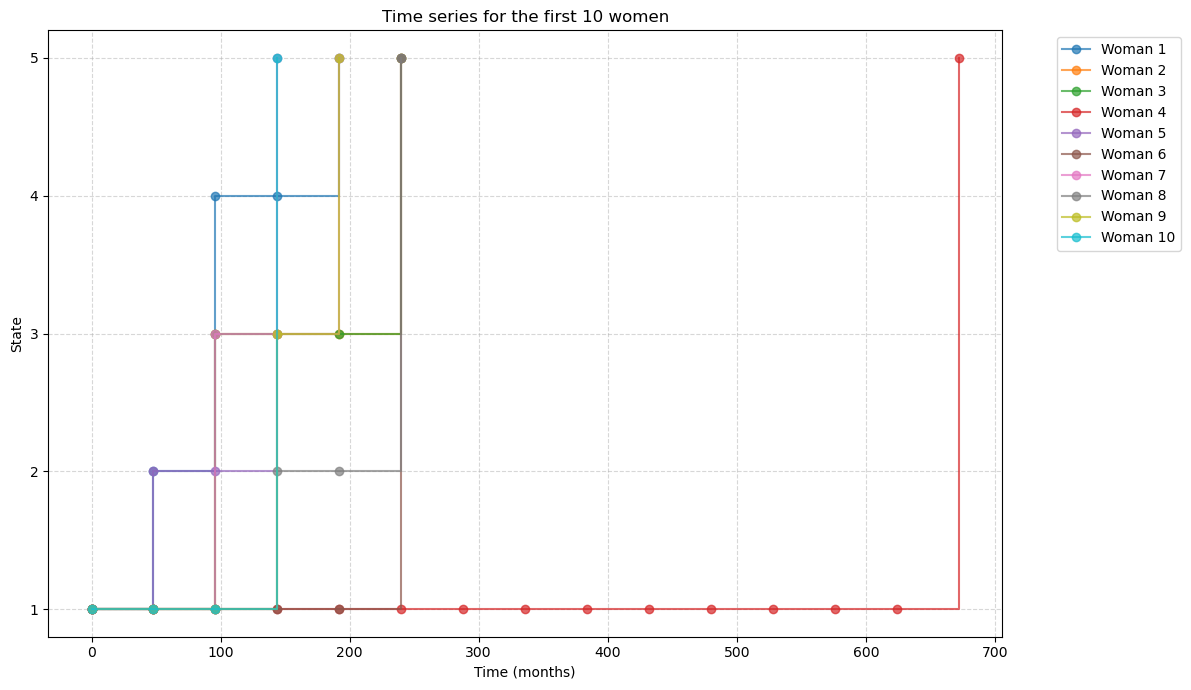

In [9]:
plt.figure(figsize=(12, 7))

# Plot the first 10 simulated women
for i in range(10):
    # Convert from 0-based indexing to 1-based states
    y_states = [state + 1 for state in observed_time_series[i]]
    
    # Creating the x-axis time points (0, 48, 96, 144, ...)
    x_times = [t * 48 for t in range(len(y_states))]
    
    plt.step(x_times, y_states, where='post', marker='o', alpha=0.7, label=f'Woman {i+1}')

# Formatting the plot
plt.title('Time series for the first 10 women')
plt.xlabel('Time (months)')
plt.ylabel('State')

# Set the y-axis ticks to show the state names for clarity
plt.yticks([1, 2, 3, 4, 5], [
    '1', 
    '2', 
    '3', 
    '4', 
    '5'
])

plt.grid(axis='both', linestyle='--', alpha=0.5)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Task 13
Assuming that the 1000 simulated time series in task 12 is all we have observed, we will now try to estimate the $q_{ij}'s following the algorithm given in the assignment.

In [16]:
# Seed for reproducibility
np.random.seed(2443)

# Choosing an initial guess Q_0
Q_0 = np.array([
    [-0.010,  0.005,  0.004,  0.000,  0.001],
    [ 0.000, -0.020,  0.010,  0.005,  0.005],
    [ 0.000,  0.000, -0.010,  0.005,  0.005],
    [ 0.000,  0.000,  0.000, -0.020,  0.020],
    [ 0.000,  0.000,  0.000,  0.000,  0.000]
])

states = [0, 1, 2, 3, 4]  # Corresponds to the states 1,2,3,4,5
max_iterations = 50       # Preventing infinite loops
tolerance = 1e-3          # Convergence criterion: ||Q^(k) - Q^(k+1)|| < 10^-3
Q_current = Q_0.copy()

print("Starting the MCEM Algorithm")

# The EM loop
for iteration in range(max_iterations):
    
    # Initialize our trackers for the M-step
    N_ij = np.zeros((5, 5)) # Total jumps from state i to j
    S_i = np.zeros(5)       # Total sojourn time spent in state i
    

    # The E step. Rejection sampling
    for patient_idx, Y_i in enumerate(observed_time_series):    # Go through every womans time series
        
        # Look at each 48-month interval (e.g., month 0 to 48, month 48 to 96)
        for m in range(len(Y_i) - 1):
            start_state = Y_i[m]
            end_state = Y_i[m+1]
            
            accepted = False
            
            # We keep simulating this 48 month gap until the end state matches the observation
            while not accepted: # While accepted = False
                sim_time = 0.0
                curr_state = start_state
                
                # Adding temporary trackers for this iteration
                temp_N = np.zeros((5, 5))
                temp_S = np.zeros(5)
                                
                while sim_time < 48.0:  # Simulate 48 months
                    
                    # If the woman dies (reaches state 5), she stays in state 5
                    if curr_state == 4:
                        temp_S[4] += (48.0 - sim_time)
                        sim_time = 48.0 # Moving 48 months forward
                        break
                        
                    lambda_i = -Q_current[curr_state, curr_state]   # The rate of leaving the current state
                    sojourn_time = np.random.exponential(scale=1/lambda_i)  # How long the woman stays in the current state
                    
                    # Checking if the jump happens after the 48 month period
                    if sim_time + sojourn_time >= 48.0:
                        # They stayed in the current state in this 48 month period
                        temp_S[curr_state] += (48.0 - sim_time)
                        sim_time = 48.0 
                    else:
                        # If the jump happens within the 48 month period
                        temp_S[curr_state] += sojourn_time
                        sim_time += sojourn_time
                        
                        # Figure out to which state they moved tod
                        jump_rates = Q_current[curr_state].copy()
                        jump_rates[curr_state] = 0
                        jump_probs = jump_rates / lambda_i
                        next_state = np.random.choice(states, p=jump_probs)
                        
                        # Record the jump
                        temp_N[curr_state, next_state] += 1
                        curr_state = next_state
                
                # Rejection sampling check
                if curr_state == end_state:
                    accepted = True
                    # Add this data to the trackers
                    N_ij += temp_N
                    S_i += temp_S

    # The M-step
    Q_next = np.zeros((5, 5))
    
    for i in range(4): # For states 1 to 4
        for j in range(5):
            if i != j:                
                if S_i[i] > 0:
                    Q_next[i, j] = N_ij[i, j] / S_i[i]  #  q_ij = N_ij / S_i
                else:
                    Q_next[i, j] = 0.0
                    
        # Setting the diagonal to the negative sum of the row
        Q_next[i, i] = -np.sum(Q_next[i])


    # Convergence check
    # Calculating the maximum absolute difference between the old Q and the new Q
    max_diff = np.max(np.abs(Q_current - Q_next))
    print(f"Iteration {iteration + 1} completed. Maximum difference = {max_diff:.6f}")
    
    Q_current = Q_next.copy()
    
    # If the change is less than 10^{-3} we are done
    if max_diff < tolerance:
        print("\nConvergence reached")
        break


# Printing the results
print("\nFinal estimated transition-rate matrix:")
np.set_printoptions(precision=4, suppress=True) # Makes the matrix print cleanly
print(Q_current)

print("\nThe original Q matrix::")
print(Q)

Starting the MCEM Algorithm
Iteration 1 completed. Maximum difference = 0.009076
Iteration 2 completed. Maximum difference = 0.000974

Convergence reached

Final estimated transition-rate matrix:
[[-0.0086  0.0052  0.0024  0.      0.001 ]
 [ 0.     -0.0143  0.006   0.0041  0.0042]
 [ 0.      0.     -0.0086  0.0041  0.0046]
 [ 0.      0.      0.     -0.01    0.01  ]
 [ 0.      0.      0.      0.      0.    ]]

The original Q matrix::
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]


We notice that the estimated Q looks very simular to the true Q matrix.